In [3]:
%load_ext autoreload
%autoreload 2

import os
from pathlib import Path

os.environ.setdefault('XDG_CACHE_HOME', str(Path('.cache').resolve()))
os.environ.setdefault('MPLCONFIGDIR', str(Path('.cache/matplotlib').resolve()))

import warnings
import matplotlib.pyplot as plt
import numpy as np
import glob
import xarray as xr
# import xgcm
import cartopy.crs as ccrs
import sys
sys.path.insert(0, '/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/src')
from src import *
from matplotlib.colors import BoundaryNorm
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from oceanttds import * 
from tqdm.notebook import tqdm
import seaborn as sns
sns.set_theme(style="whitegrid", context="notebook")

import jax
import jax.numpy as jnp
import numpyro
import xarray_jax  # noqa: F401 - registers xarray objects as JAX pytrees
from numpyro import distributions as dist, sample
from numpyro.infer import MCMC, NUTS, Predictive
numpyro.set_host_device_count(4)
jax.local_device_count()


4

In [4]:
import oceanttds
oceanttds

<module 'oceanttds' from '/vortexfs1/home/anthony.meza/miniforge3/envs/cm4x_chapter3/lib/python3.13/site-packages/oceanttds/__init__.py'>

In [5]:
import cmocean.cm as cmo

In [6]:
ds_path = "/proj/ecco/CM4X/budget_sigma2_v1.2.0/CM4Xp125_budgets_sigma2_2010-2014.zarr"
ds = xr.open_mfdataset(ds_path)

In [7]:
ds_path = "/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/data/model/bottom_tracers_yearly.zarr"
ds = xr.open_mfdataset(ds_path)
ds = ds.sel(year = slice(None, 2099))
ds = ds.where(ds.depth < -2500)

In [8]:
ds_path = "/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/data/model/adelie_ross_boundary_sample_for_ttd.zarr"
ds_b = xr.open_mfdataset(ds_path).compute().rename({"year":"time", "__xarray_dataarray_variable__":"boundary_truth"}).fillna(0.0)

ds_path = "/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/data/model/adelie_ross_interior_sample_for_ttd.zarr"
ds_i = xr.open_mfdataset(ds_path).compute().rename({"year":"time", "__xarray_dataarray_variable__": "interior_truth"}).fillna(0.0)

In [9]:
regions = {
    "weddell": {
        "extent": [-70, -19, -79, -59],
        "central_longitude": 0,
        "xticks": np.arange(-60, -19, 20),
        "yticks": np.arange(-76, -59, 4),
        "labels": [(-40, -70, "Weddell\nSea")],
    },
    "prydz": {
        "extent": [15, 95, -73, -59],
        "central_longitude": 0,
        "xticks": np.arange(20, 100, 20),
        "yticks": np.arange(-72, -59, 4),
        "labels": [(53, -71, "Prydz\nBay")],
    },
    "adelie_ross": {
        "extent": [100, 200, -79, -59],
        "central_longitude": 180,
        "xticks": [100, 120, 140, 160, 180, -160, -140],
        "yticks": np.arange(-76, -59, 4),
        "labels": [(130, -70, "Adélie\nCoast"), (150, -78, "Ross\nSea")],
    },
}

KeyboardInterrupt: 

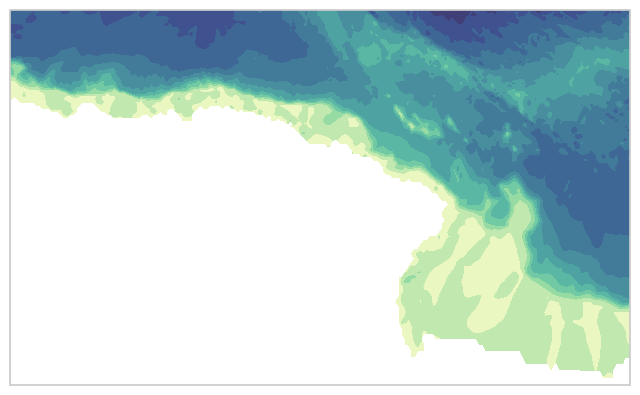

In [ ]:
import matplotlib.ticker as mticker
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

add_land = lambda ax: ax.add_feature(cfeature.LAND, facecolor="lightgrey", edgecolor="none")

proj = ccrs.PlateCarree()
region = regions["adelie_ross"]
fig = plt.figure(figsize=(8, 5))
gs = fig.add_gridspec(1, 2, wspace=0.5)

ax = fig.add_subplot(
    gs[0, :2],
    projection=ccrs.Mercator(
        central_longitude=region["central_longitude"],
        min_latitude=-80,
        max_latitude=-50,
        latitude_true_scale=-70,
    ))

ax.set_extent(region["extent"], crs=proj)

depth = ds.deptho.where(ds.deptho > 10).compute()
levels = np.arange(0, 7000, 500)

pc = ax.contourf(ds["geolon"], ds["geolat"], depth,
                 transform=proj, levels = levels,extend = "max", 
                cmap = cmo.deep)

for source in ds_b.source.values:
    ds_b_source = ds_b.sel(source = source)
    ax.scatter(ds_b_source.lon, ds_b_source.lat,transform=proj, c="k", zorder=10,s = 160, marker = "*")

ax.scatter(ds_i.lon, ds_i.lat,transform=proj, c="r", zorder=10,s = 160, marker = "*", label = "Bottom interior sample location")

add_land(ax)

legend = ax.legend(loc='upper right')
legend.set_zorder(15) #

gl = ax.gridlines(draw_labels=False, crs=proj, alpha=0.1)
gl.xlocator = mticker.FixedLocator(region["xticks"])
gl.ylocator = mticker.FixedLocator(region["yticks"])

ax.set_xticks(region["xticks"], crs=proj)
ax.set_yticks(region["yticks"], crs=proj)
ax.xaxis.set_major_formatter(LongitudeFormatter(dateline_direction_label=True))
ax.yaxis.set_major_formatter(LatitudeFormatter())

fig.colorbar(pc, ax = ax, orientation = "horizontal", shrink = 0.5, label = "Depth [m]")

fig.savefig('plots/1.ttd_example_locations.png', dpi = 150, bbox_inches = "tight")

In [ ]:
final_obs_year = 2099

ds_b = ds_b.sel(tracer = ["cfc11", "cfc12", "sf6"])
ds_b["boundary"] = ds_b["boundary_truth"].fillna(0.0).copy()
ds_b = ds_b.sel(time = slice(None, final_obs_year))

ds_i = ds_i.sel(tracer = ["cfc11", "cfc12", "sf6"])
ds_i["interior"] = ds_i["interior_truth"].fillna(0.0).copy()
ds_i = ds_i.sel(time = slice(1940, final_obs_year))

noise_floors = np.array([0.01, 0.01, 0.01])
ds_i = ds_i.assign(noise_floors=(("tracer",), noise_floors))
ds_i["sigma_obs"] = ds_i["noise_floors"].broadcast_like(ds_i["interior"])

truth = ds_i.copy()

In [10]:
expt_colors = {"forced":"r", "control":"b"}
variable_units = {"cfc11":r"pmol kg$^{-1}$", "cfc12":r"pmol kg$^{-1}$", "sf6":r"fmol kg$^{-1}$"}
variable_names = {"cfc11":r"CFC-11", "cfc12":r"CFC-12", "sf6":r"SF$_\mathbf{6}$"}

expt_names = {"forced":"Historical/SSP5-8.5", "control":"piControl"}



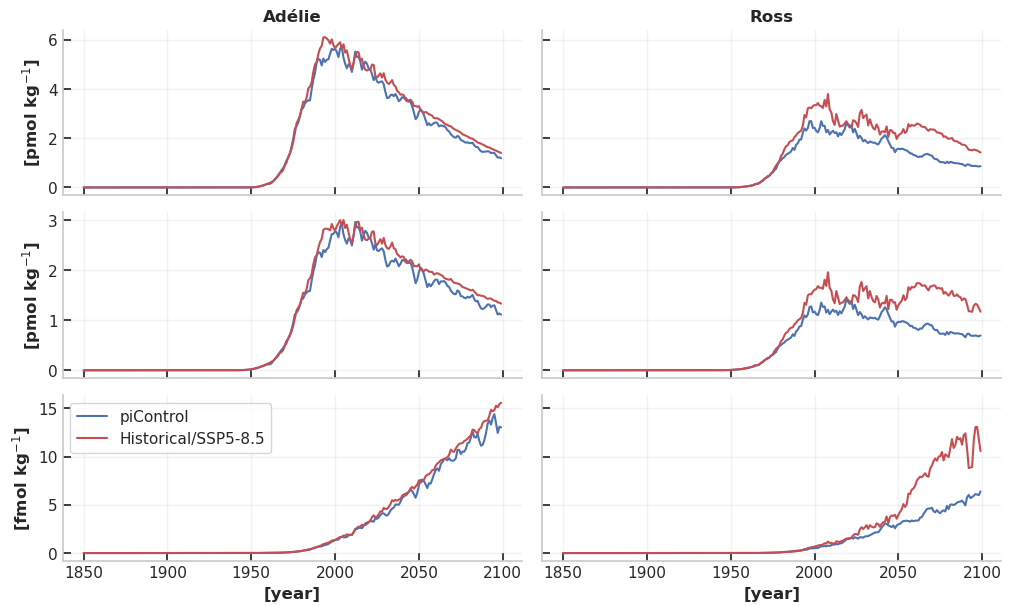

In [11]:
ntracer, nsource = ds_b.sizes["tracer"], ds_b.sizes["source"]

fig, axs = plt.subplots(
    ntracer, nsource,
    figsize=(10, 6),
    sharex=True,
    sharey="row",
    constrained_layout=True,
    gridspec_kw={"wspace": 0.04, "hspace": 0.08},
)

for i, tracer in enumerate(ds_b.tracer.values):
    for j, source in enumerate(ds_b.source.values):
        ax = axs[i, j]

        for expt in ds_b.expt.values:
            ax.plot(
                ds_b.time,
                ds_b.boundary.sel(source=source, tracer=tracer, expt=expt),
                c=expt_colors[expt],
                lw=1.5,
                label=expt_names[expt],
            )

        if i == 0:
            ax.set_title(
                ds_b.boundary.sel(source=source)["print_name"].item(),
                weight="bold",
            )
        if j == 0:
            ax.set_ylabel(f"[{variable_units[tracer]}]", fontweight = "bold")
        if i == ntracer-1:
            ax.set_xlabel(f"[year]", fontweight = "bold")
        ax.grid(alpha=0.25)
        ax.tick_params(direction="in", bottom=True, left=True, top=False, right=False)
        ax.spines[["top", "right"]].set_visible(False)

axs[-1, 0].legend(frameon=True)

Text(0.52, 1.1, 'Model interior histories')

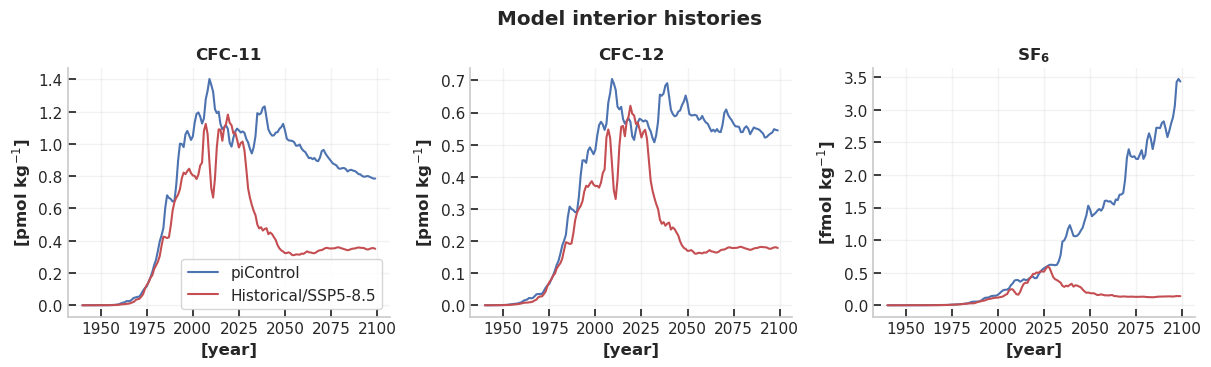

In [12]:
def plot_error_band(ax, time, history, error, label, color, legend=None, alpha=0.25):
    if legend is None:
        legend = {}

    ax.fill_between(time, history - 2 * error, history + 2 * error,
                    color=color, alpha=alpha, linewidth=0)
    line, = ax.plot(time, history, color=color)

    legend[label] = line
    return legend

fig, axs = plt.subplots(
    1, ds_i.sizes["tracer"],
    figsize=(12, 3.2),
    sharex=True,
    constrained_layout=True,
    gridspec_kw={"wspace": 0.04},
)

legend = {}

for ax, tracer in zip(axs, ds_i.tracer.values):
    for expt in ds_i.expt.values:
        y = ds_i.interior.sel(tracer=tracer, expt=expt)

        ax.plot(
            ds_i.time,
            y,
            c=expt_colors[expt],
            lw=1.5,
            label=expt_names[expt],)

    ax.set_title(variable_names[tracer], weight="bold")
    ax.set_xlabel("[year]", weight="bold")
    ax.set_ylabel(f"[{variable_units[tracer]}]", weight="bold")
    ax.grid(alpha=0.25)
    ax.tick_params(direction="in", bottom=True, left=True, top=False, right=False)
    ax.spines[["top", "right"]].set_visible(False)

axs[0].legend(frameon=True)
fig.suptitle('Model interior histories', fontweight='bold', y = 1.1, x = 0.52)


In [13]:
from plot_ig_utils import *
from utils import *

bayes_integrator = TTDIntegrator(order=61)

def two_source_numpyro_model(ds_i, ds_b):
    n_source = ds_b.sizes['source']
    gamma = sample('gamma', dist.Uniform(1.0, 1_000.0), sample_shape=(n_source,))
    delta_gamma_ratio = sample('delta_gamma_ratio', dist.Uniform(0.5, 2.0), sample_shape=(n_source,))
    mass_fraction = sample('mass_fraction', dist.Dirichlet(jnp.ones(n_source)))
    delta = gamma * delta_gamma_ratio

    gamma_da = xr.DataArray(gamma, dims='source', coords={'source': ds_b.source})
    delta_da = xr.DataArray(delta, dims='source', coords={'source': ds_b.source})
    mf_da = xr.DataArray(mass_fraction, dims='source', coords={'source': ds_b.source})
    age = EnsembleMixture(
        components=[
            (
                str(source),
                InverseGaussian,
                {
                    'gamma': gamma_da.sel(source=source),
                    'delta': delta_da.sel(source=source),
                },
            )
            for source in ds_b.source.values
        ],
        mass_fractions=mf_da,
        source_dim='source',
    )
    mu = bayes_integrator.predict_sources(
        age=age,
        obs_times=ds_i['time'],
        boundary=ds_b['boundary'],
    )
    
    sample('obs', dist.Normal(loc=mu.data, scale=ds_i['sigma_obs'].data), obs=ds_i['interior'].data)

In [14]:
# Correct
import numpyro.optim as optim
from numpyro.infer import MCMC, NUTS, SVI, Trace_ELBO, autoguide
from numpyro.infer.initialization import init_to_value, init_to_uniform, init_to_sample
def add_timescale_vars(ds):
    ds["delta"] = ds["gamma"] * ds["delta_gamma_ratio"]
    ds["peclet"] = ds["delta_gamma_ratio"] ** 2 / 2.0
    ds["advective_timescale"] = ds["gamma"]
    ds["peclet_number"] = ds["peclet"]
    ds["diffusive_timescale"] = ds["gamma"] * ds["peclet"]
    return ds


def run_mcmc(ds_i, ds_b, expt=None, use_intialization_strategy = True):
    ds_i_e, ds_b_e = ds_i.sel(expt=expt), ds_b.sel(expt=expt)

    if use_intialization_strategy: 
        # 1. Setup SVI with AutoLaplaceApproximation to find the MAP
        # (We pass the model arguments to the guide so it knows the shapes)
        guide = autoguide.AutoDelta(two_source_numpyro_model)
        optimizer = optim.Adam(step_size=0.01)
        svi = SVI(two_source_numpyro_model, guide, optimizer, loss=Trace_ELBO())
        
        # Run a quick optimization block to find the peak
        rng_key = jax.random.PRNGKey(0)
        rng_key_svi, rng_key_mcmc = jax.random.split(rng_key)
        
        print("Running AutoDelta approximation for initialization...")
        svi_result = svi.run(
            rng_key_svi, 
            num_steps=1000,          # 1000 steps is usually plenty for init
            ds_i=ds_i_e,           # Pass your exact model data arguments here
            ds_b=ds_b_e
        )
        
        # 2. Extract the MAP values (the mode) from the Laplace guide
        # This replaces your manual dictionary completely
        laplace_init_values = guide.sample_posterior(
            rng_key_svi, 
            svi_result.params, 
            sample_shape=(1,)
        )
        # Squeeze out the sample dimension to get a clean dictionary of parameters
        init_values = {k: jnp.squeeze(v, axis=0) for k, v in laplace_init_values.items()}
        init_strategy = init_to_value(values=init_values)
        num_chains = 4
        dense_mass = False
        print("Laplace initialization complete. Starting NUTS...")
    else: 
        init_strategy = init_to_uniform(radius = 4.0)
        num_chains = 6
        dense_mass = True
    
    # 3. Pass the automatically discovered values into NUTS

    kernel = NUTS(two_source_numpyro_model, target_accept_prob=0.98, dense_mass = dense_mass,     
                  init_strategy=init_strategy,)
    mcmc = MCMC(kernel, num_warmup=10_000, num_samples=7_500, num_chains=num_chains,
                chain_method="parallel", progress_bar=True)

    mcmc.run(
        jax.random.PRNGKey(2212), ds_i=ds_i_e, ds_b=ds_b_e,
        extra_fields=("diverging", "potential_energy", "num_steps", "accept_prob"),
    )

    extra = mcmc.get_extra_fields(group_by_chain=True)
    n_divergent = int(np.asarray(extra["diverging"]).sum())
    print("n_divergent =", n_divergent)

    for key in ["num_steps", "accept_prob", "potential_energy"]:
        y = np.asarray(extra[key])
        print(f"\n{key}")
        for c in range(y.shape[0]):
            print(f"chain {c}: mean={y[c].mean():.3g}, "
                  f"p95={np.quantile(y[c], 0.95):.3g}, max={y[c].max():.3g}")

    posterior = flatten_numpyro_output(posterior=mcmc, source=ds_b_e.source)
    posterior = posterior.assign_coords(sample=np.arange(posterior.sizes["sample"]))
    posterior = add_timescale_vars(posterior)
    print("\nn_posterior =", posterior.sizes["sample"])

    prior_draws = Predictive(two_source_numpyro_model, num_samples=posterior.sizes["sample"])(
        jax.random.PRNGKey(98712), ds_i=ds_i_e, ds_b=ds_b_e
    )

    prior = flatten_numpyro_output(group="prior", prior=prior_draws,
                                   sample_dims=["sample"], sample=posterior["sample"],
                                   source=ds_b_e.source)
    prior = add_timescale_vars(prior)
    mcmc.print_summary()
    return mcmc, prior, posterior

In [15]:
ds_b = ds_b.assign(source=ds_b.source.astype(str))

mcmc_control, prior_control, posterior_control = run_mcmc(ds_i.compute(), ds_b.compute(), expt = "control", 
                                                          use_intialization_strategy = True)

Running AutoDelta approximation for initialization...


100%|██████████| 1000/1000 [00:04<00:00, 233.74it/s, init loss: 1528245.6250, avg. loss [951-1000]: 13393.1953]


Laplace initialization complete. Starting NUTS...


  0%|          | 0/17500 [00:00<?, ?it/s]

  0%|          | 0/17500 [00:00<?, ?it/s]

  0%|          | 0/17500 [00:00<?, ?it/s]

  0%|          | 0/17500 [00:00<?, ?it/s]

n_divergent = 0

num_steps
chain 0: mean=104, p95=191, max=255
chain 1: mean=101, p95=191, max=255
chain 2: mean=90.4, p95=159, max=255
chain 3: mean=123, p95=255, max=383

accept_prob
chain 0: mean=0.98, p95=1, max=1
chain 1: mean=0.977, p95=1, max=1
chain 2: mean=0.969, p95=1, max=1
chain 3: mean=0.986, p95=1, max=1

potential_energy
chain 0: mean=1.02e+04, p95=1.02e+04, max=1.02e+04
chain 1: mean=1.02e+04, p95=1.02e+04, max=1.02e+04
chain 2: mean=1.02e+04, p95=1.02e+04, max=1.02e+04
chain 3: mean=1.02e+04, p95=1.02e+04, max=1.02e+04

n_posterior = 30000

                          mean       std    median      5.0%     95.0%     n_eff     r_hat
delta_gamma_ratio[0]      0.50      0.00      0.50      0.50      0.50  17428.03      1.00
delta_gamma_ratio[1]      0.91      0.02      0.91      0.88      0.94   6896.65      1.00
            gamma[0]      8.19      0.05      8.19      8.10      8.28   8870.89      1.00
            gamma[1]    353.95      8.83    353.69    339.46    368.44  

In [16]:
mcmc_forced, prior_forced, posterior_forced = run_mcmc(ds_i.compute(), ds_b.compute(), expt = "forced", 
                                                          use_intialization_strategy = True)

Running AutoDelta approximation for initialization...


100%|██████████| 1000/1000 [00:04<00:00, 244.18it/s, init loss: 288212.7188, avg. loss [951-1000]: 229920.0781]


Laplace initialization complete. Starting NUTS...


  0%|          | 0/17500 [00:00<?, ?it/s]

  0%|          | 0/17500 [00:00<?, ?it/s]

  0%|          | 0/17500 [00:00<?, ?it/s]

  0%|          | 0/17500 [00:00<?, ?it/s]

n_divergent = 0

num_steps
chain 0: mean=26.3, p95=47, max=79
chain 1: mean=25.4, p95=47, max=63
chain 2: mean=26.1, p95=47, max=95
chain 3: mean=28.2, p95=63, max=95

accept_prob
chain 0: mean=0.98, p95=1, max=1
chain 1: mean=0.978, p95=1, max=1
chain 2: mean=0.979, p95=1, max=1
chain 3: mean=0.98, p95=1, max=1

potential_energy
chain 0: mean=2.29e+05, p95=2.29e+05, max=2.29e+05
chain 1: mean=2.29e+05, p95=2.29e+05, max=2.29e+05
chain 2: mean=2.29e+05, p95=2.29e+05, max=2.29e+05
chain 3: mean=2.29e+05, p95=2.29e+05, max=2.29e+05

n_posterior = 30000

                          mean       std    median      5.0%     95.0%     n_eff     r_hat
delta_gamma_ratio[0]      0.50      0.00      0.50      0.50      0.50  12911.23      1.00
delta_gamma_ratio[1]      0.50      0.00      0.50      0.50      0.50  22469.82      1.00
            gamma[0]    492.80      3.21    492.59    487.46    497.83  12180.59      1.00
            gamma[1]     21.03      0.24     21.03     20.62     21.43  12425.

In [17]:
def concat_by_expt(ds_control, ds_forced): 
    ds_out = xr.concat([ds_control, ds_forced], dim="expt")
    ds_out = ds_out.assign_coords(expt=["control", "forced"])
    return ds_out

def calculate_mixture_parameters(ds): #from the definitions of Gamma and Delta 
    f = ds["mass_fraction"]
    gamma = ds["gamma"]
    delta = ds["delta"]
    
    ds["gamma_mix"] = (f * gamma).sum("source")
    
    ds["delta_mix"] = np.sqrt(
        (f * delta**2).sum("source")
        + (f * (gamma - posterior["gamma_mix"])**2).sum("source"))
    return ds

In [18]:
posterior = concat_by_expt(posterior_control, posterior_forced)
prior = concat_by_expt(prior_control, prior_forced)

posterior = calculate_mixture_parameters(posterior)
prior = calculate_mixture_parameters(prior)

In [19]:
tracer_ds = xr.merge([ds_i.rename({"time":"interior_time"}), ds_b.rename({"time":"boundary_time"})], compat = "override")
bayes_ds = xr.concat([prior, posterior], dim="distribution")
bayes_ds = bayes_ds.assign_coords(distribution=["prior", "posterior"])

In [20]:
merged_ds = xr.merge([bayes_ds, tracer_ds], compat='override')
merged_ds.to_netcdf("/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/data/model/bayesian_inverse_gaussian_results.nc")

In [21]:
percent = xr.DataArray(
    np.arange(2.5, 50.0 + 2.5, 2.5),
    dims='percent',
    name='percent',
    attrs={'units': '%'},
)
ventilation_fraction = (percent / 100.0).assign_coords(percent=percent)
tau_grid = xr.DataArray(
    np.geomspace(0.1, 20000.0, 300),
    dims='tau',
    name='tau',
    attrs={'units': 'years'},
)

def ensemble_mixture(samples):
    return EnsembleMixture(
        components=[
            (
                str(source),
                InverseGaussian,
                {
                    'gamma': samples['gamma'].sel(source=source),
                    'delta': samples['delta'].sel(source=source),
                },
            )
            for source in samples.source.values
        ],
        mass_fractions=samples['mass_fraction'],
        source_dim='source',
    )

def mixture_curve(samples):
    return ensemble_mixture(samples).ppf(ventilation_fraction, tau_grid)

prior['mixture_ventilation_time'] = mixture_curve(prior)
posterior['mixture_ventilation_time'] = mixture_curve(posterior)

prior['mixture_vent10'] = prior['mixture_ventilation_time'].sel(percent=10.0)
posterior['mixture_vent10'] = posterior['mixture_ventilation_time'].sel(percent=10.0)

In [22]:
prior_da = bayes_integrator.predict_sources(
    age=ensemble_mixture(prior),
    obs_times=ds_i['time'],
    boundary=ds_b['boundary'],
)
posterior_da = bayes_integrator.predict_sources(
    age=ensemble_mixture(posterior),
    obs_times=ds_i['time'],
    boundary=ds_b['boundary'],
)

posterior_da_components = bayes_integrator.predict_sources(
    age=ensemble_mixture(posterior),
    obs_times=ds_i['time'],
    boundary=ds_b['boundary'],
    return_components=True
)

In [ ]:
posterior_da_components

In [ ]:
import string
import matplotlib.pyplot as plt
import seaborn as sns


def plot_error_band(ax, time, history, error, label, color, legend=None, alpha=0.25):
    legend = {} if legend is None else legend

    ax.fill_between(time, history - 2 * error, history + 2 * error,
                    color=color, alpha=alpha, linewidth=0)
    line, = ax.plot(time, history, color=color)

    legend[label] = line
    return legend


sns.set_theme(style="whitegrid", context="notebook")

expts, tracers = list(ds_b.expt.values), list(ds_i.tracer.values)

# --- CHANGED: Removed the + 1 row since we are deleting the top plot ---
nrows, ncols = len(expts), len(tracers)

fig = plt.figure(figsize=(3.5 * ncols * 1.1, 2.7 * nrows * 1.1), constrained_layout=True)

# --- CHANGED: Cleaned up grid spec height ratios to remove the TTD row ---
gs = fig.add_gridspec(nrows, ncols, hspace=0.1, wspace=0.07)

ax_ref = None
# --- CHANGED: Started at 'a' instead of skipping to 'b' ---
panel_letters = iter(string.ascii_lowercase)

# --- CHANGED: Started loop at 0 instead of 1 ---
for row, expt in enumerate(expts, start=0):
    color = expt_colors[str(expt)]

    for col, tracer in enumerate(tracers):
        ax = fig.add_subplot(gs[row, col], sharex=ax_ref)
        ax_ref = ax if ax_ref is None else ax_ref

        tracer = str(tracer)
        units = variable_units.get(tracer, "concentration")
        legend = {}

        plot_error_band(ax, ds_i.time,
                        ds_i.interior.sel(tracer=tracer, expt=expt),
                        ds_i.sigma_obs.sel(tracer=tracer, expt=expt),
                        r"Model±error tol.", "k", legend=legend, alpha=0.18)

        plot_distribution(ax, ds_i.time,
                          posterior_da.sel(tracer=tracer, expt=expt),
                          color, "TTD estimate", legend=legend)

        ax.set_ylabel(f"[{units}]")
        ax.grid(alpha=0.7)
        ax.legend(
            legend.values(), legend.keys(),
            title=str(expt).capitalize() + ":",
            fontsize=10,
            title_fontsize=10,
            alignment="left",
        )

        # --- CHANGED: Adjusted title handling to check for row 0 ---
        if row == 0:
            ax.set_title(str(tracer).upper(), fontweight="bold")
            
        # --- CHANGED: Adjusted bottom labels checking against the new grid size ---
        if row == len(expts) - 1:
            ax.set_xlabel("Time")
        else:
            ax.tick_params(labelbottom=False)

        ax.text(0.98, 0.04, next(panel_letters), transform=ax.transAxes,
                ha="right", va="bottom", fontweight="bold", fontsize=14)
        ax.set_xlim(1900, None)

for ax in fig.axes:
    ax.grid(alpha = 0.3)
    ax.tick_params(direction="in", bottom=True, left=True,
                    top=False, right=False)

In [ ]:
import importlib
import plot_ig_utils

plot_ig_utils = importlib.reload(plot_ig_utils)
plot_variable_marginals = plot_ig_utils.plot_variable_marginals

prior_color = 'tab:orange'
posterior_color = 'tab:blue'
truth_color = 'k'
kde_kws = {'cut': 0, 'clip': (0, np.inf), 'bw_adjust': 0.2}
hist_kws = dict(bins=35, stat='probability', alpha=0.35, kde=True, kde_kws=kde_kws)
diagnostic_names = ['advective_timescale', 'diffusive_timescale', 'peclet_number', 'delta_gamma_ratio']
target_diagnostics = ['Advective Timescale', 'Diffusive Timescale', 'Peclet Number', r'$\Delta / \Gamma$']

for expt in ds_b.expt.values:
    print(expt)
    for source in ds_b.source.values:
        fig, axes = plot_variable_marginals(
            prior.sel(expt = expt),
            posterior.sel(expt = expt),
            diagnostic_names,
            target_diagnostics,
            source=source,
            prior_color=prior_color,
            posterior_color=posterior_color,
            hist_kws=hist_kws,
        )
        for ax, units in zip(axes.ravel(), ['years', 'years', 'unitless', 'unitless'], strict=True):
            ax.set_xlabel(units)
        fig.suptitle(f'{expt}: Source {source} derived diagnostics', fontweight='bold', y=1.03)
        

In [ ]:
fig, ax = plt.subplots(1, 2)


ds_i.interior.sel(tracer= "cfc11", expt = "control").plot(ax = ax[0])
posterior_da.sel(tracer= "cfc11", expt = "control").median("sample").plot(ax = ax[0])

posterior_da_components.sel(tracer = "cfc11", expt = "control").median("sample").isel(_source_term = 0).plot(ax = ax[1])
posterior_da_components.sel(tracer = "cfc11", expt = "control").median("sample").isel(_source_term = 1).plot(ax = ax[1])

In [ ]:
parameter_names = ['gamma', 'delta', 'mass_fraction']
target_parameters = [
    r'$\mathbf{\Gamma}$ (Mean age parameter)',
    r'$\Delta$ (Age width parameter)',
    'Mass Fraction',
]

for expt in ds_b.expt.values:
    for source in ds_b.source.values:
        fig, axes = plot_variable_marginals(
            prior.sel(expt = expt),
            posterior.sel(expt = expt),
            parameter_names,
            target_parameters,
            source=source,
            prior_color=prior_color,
            posterior_color=posterior_color,
            hist_kws=hist_kws,
        )
        for ax, units in zip(axes.ravel(), ['years', 'years', 'unitless', 'years'], strict=False):
            ax.set_xlabel(units)
        fig.suptitle(f'{expt}: Source {source} scalar diagnostics', fontweight='bold', y=1.03)

In [ ]:
parameter_names = ['gamma_mix', 'delta_mix']
target_parameters = [
    r'$\mathbf{\Gamma}_{mix}$ (Mixed mean age parameter)',
    r'$\Delta_{mix}$ (Mixed age width parameter)'
]

for expt in ds_b.expt.values:
        fig, axes = plot_variable_marginals(
            prior.sel(expt = expt),
            posterior.sel(expt = expt),
            parameter_names,
            target_parameters,
            source=source,
            prior_color=prior_color,
            posterior_color=posterior_color,
            hist_kws=hist_kws,
        )
        for ax, units in zip(axes.ravel(), ['years', 'years',], strict=False):
            ax.set_xlabel(units)
        fig.suptitle(f'{expt}: Mixed scalar diagnostics', fontweight='bold', y=1.03)